In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from config import *

from lisaorbits import KeplerianOrbits, StaticConstellation
from scipy.signal import coherence

import warnings
warnings.filterwarnings("ignore")

In [2]:
def make_tdi_dict(X, Y, Z, whiten=True):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        if whiten:
            psd_data = np.load(PSD_PATH / f'psd_{name}.npz')
            f_psd, psd = psd_data['f_psd'], psd_data['psd']
            tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd, alpha=0.1)
        else:
            tdi_dict[name] = channel_data[i]
    return tdi_dict

## Gravitational Waves

In [34]:
#gw_dataset_path = '../dist/gw_ehm_dataset.h5'

with h5py.File(gw_lm_dataset_path, "r") as h5:
    X_array = h5["X"][:]       # shape (N, 512, 512)
    Y_array = h5["Y"][:]       # shape (N, 512, 512)
    Z_array = h5["Z"][:]       # shape (N, 512, 512)
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin1_array = h5["spin1"][:]
    spin2_array = h5["spin2"][:]
    gw_beta_array = h5["gw_beta"][:]
    gw_lambda_array = h5["gw_lambda"][:]

In [38]:
index = 56  # Change this index to visualize different samples
m1 = m1_array[index]
m2 = m2_array[index]
d = d_array[index]
spin1 = spin1_array[index]
spin2 = spin2_array[index]
gw_beta = gw_beta_array[index]
gw_lambda = gw_lambda_array[index]

pipe = {'t0': 10368000, 'dt': 0.25,'size': 10 * 3600 / 0.25,
            't_inj': 5 * 3600}

gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj'], 'domain': 'freq'}]

tdi_dict = make_tdi_dict(X_array[index], Y_array[index], Z_array[index], whiten=True)

specs = {'low_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

chirp = chirp_mass(m1, m2)

if chirp < 1e5:
    spec = specs['low_mass']
elif chirp < 1e6:
    spec = specs['high_mass']
else:
    spec = specs['ext_high_mass']

In [52]:
event = {'t_inj': pipe['t_inj'] - 1*3600}
channel = 'A'
res = 256

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

4.841243743896484


In [53]:
(t_arr2[-1] - t_arr2[0])/3600

6.008757638868293

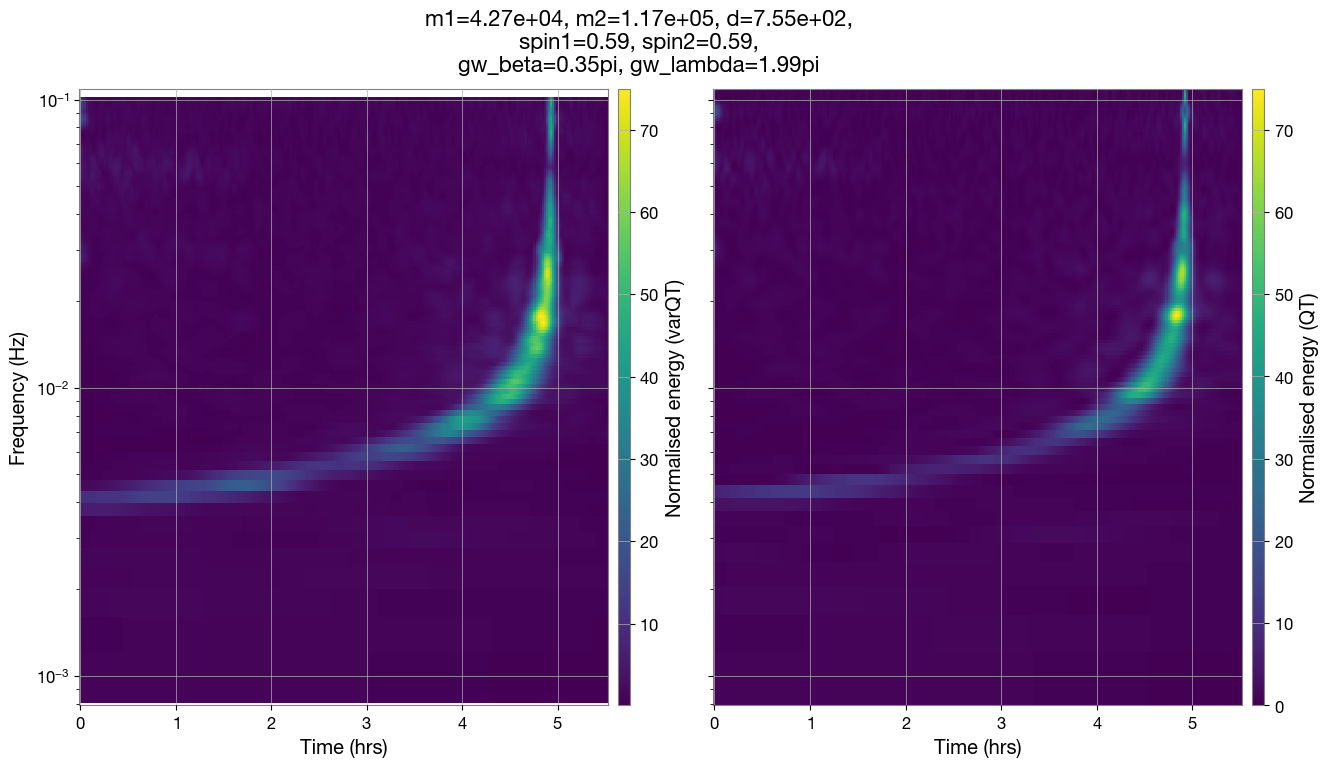

In [47]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
title = f'm1={m1:.2e}, m2={m2:.2e}, d={d:.2e}, \n' +\
    f'spin1={spin1:.2f}, spin2={spin2:.2f}, \n' +\
    f'gw_beta={gw_beta/np.pi:.2f}pi, gw_lambda={gw_lambda/np.pi:.2f}pi \n'
fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()

## Glitches

In [54]:
with h5py.File(glitch_dataset_path, "r") as h5:
    X_array = h5["X"][:]       # shape (N, 512, 512)
    Y_array = h5["Y"][:]       # shape (N, 512, 512)
    Z_array = h5["Z"][:]       # shape (N, 512, 512)
    level_array = h5["level"][:]
    beta_array = h5["beta"][:]
    inj_point_array = h5["inj_point"][:]

print(f"This dataset has {len(X_array)} samples.")

This dataset has 1020 samples.


In [168]:
index = 30 # Change this index to visualize different samples
level = level_array[index]
beta = beta_array[index]
inj_point = inj_point_array[index]

pipe = {'t0': 10368000, 'dt': 0.25,'size': 10 * 3600 / 0.25,
            't_inj': 5 * 3600}

glitches = [{'type':'ShapeletGlitch', 't_inj': pipe['t_inj'], 'beta':beta,
            'level':level, 'inj_point':inj_point}]

tdi_dict = make_tdi_dict(X_array[index], Y_array[index], Z_array[index], whiten=True)

specs = {'low_mass': {'trange':(-2, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-2, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-2, 2), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}


In [169]:
event = glitches[0]
channel = 'A'
res = 256
spec = specs['high_mass']

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

2.0955100059509277


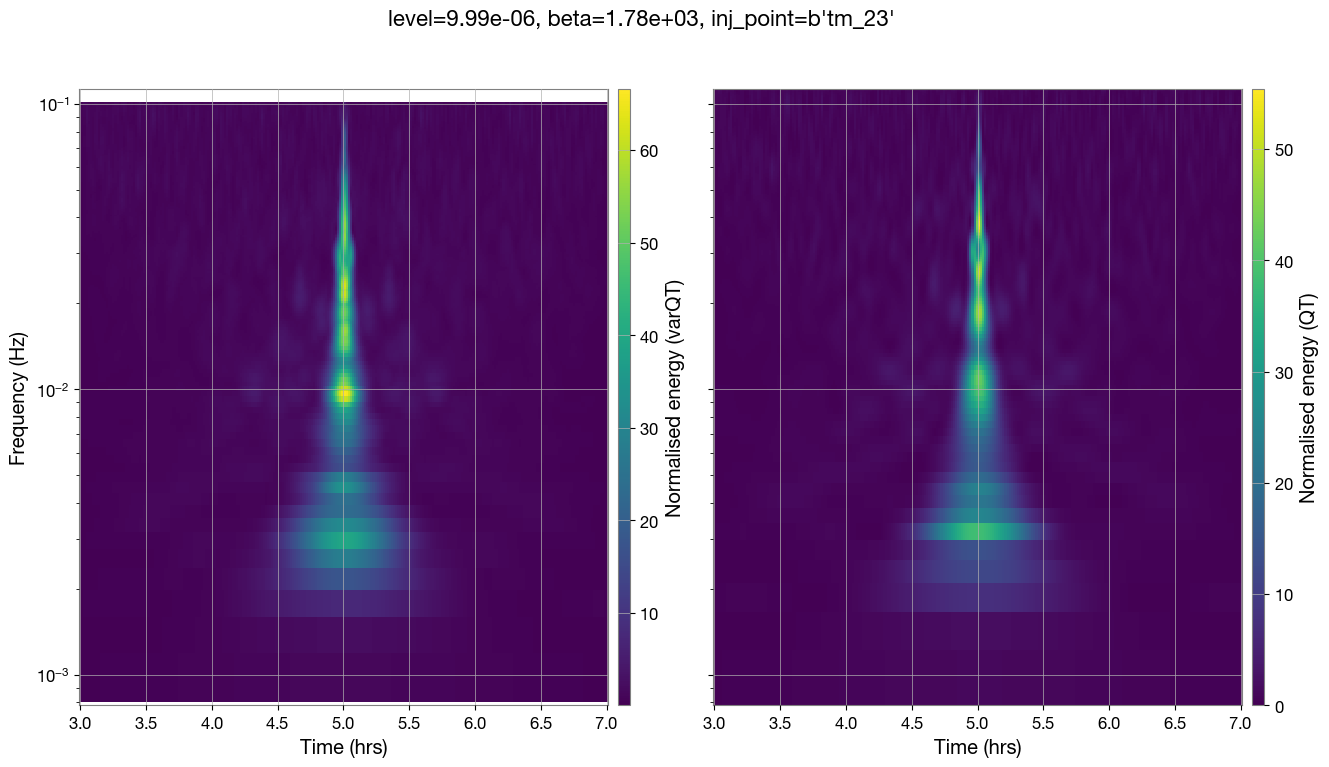

In [170]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
title = f'level={event["level"]:.2e}, beta={event["beta"]:.2e}, inj_point={event["inj_point"]}'
fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()

## GW + Glitch

In [236]:
with h5py.File(mixed_lm_dataset_path, "r") as h5:
    X_array = h5["X"][:]       # shape (N, 512, 512)
    Y_array = h5["Y"][:]       # shape (N, 512, 512)
    Z_array = h5["Z"][:]       # shape (N, 512, 512)
    level_array = h5["level"][:]
    beta_array = h5["beta"][:]
    inj_point_array = h5["inj_point"][:]
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin1_array = h5["spin1"][:]
    spin2_array = h5["spin2"][:]
    gw_beta_array = h5["gw_beta"][:]
    gw_lambda_array = h5["gw_lambda"][:]
    sep_array = h5["sep"][:]

In [237]:
index = 263  # Change this index to visualize different samples
m1 = m1_array[index]
m2 = m2_array[index]
d = d_array[index]
spin1 = spin1_array[index]
spin2 = spin2_array[index]
gw_beta = gw_beta_array[index]
gw_lambda = gw_lambda_array[index]
level = level_array[index]
beta = beta_array[index]
inj_point = inj_point_array[index]
sep = sep_array[index]

pipe = {'t0': 10368000, 'dt': 0.25,'size': 10 * 3600 / 0.25,
            't_inj': 5 * 3600}

gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj'], 'domain': 'freq'}]

glitches = [{'type':'ShapeletGlitch', 't_inj': pipe['t_inj'], 'beta':beta,
            'level':level, 'inj_point':inj_point}]

tdi_dict = make_tdi_dict(X_array[index], Y_array[index], Z_array[index], whiten=True)

specs = {'low_mass': {'trange':(-3, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

chirp = chirp_mass(m1, m2)

if chirp < 1e5:
    spec = specs['low_mass']
elif chirp < 1e6:
    spec = specs['high_mass']
else:
    spec = specs['ext_high_mass']

In [238]:
event = {'t_inj': pipe['t_inj']}
channel = 'E'
res = 256

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

3.867644786834717


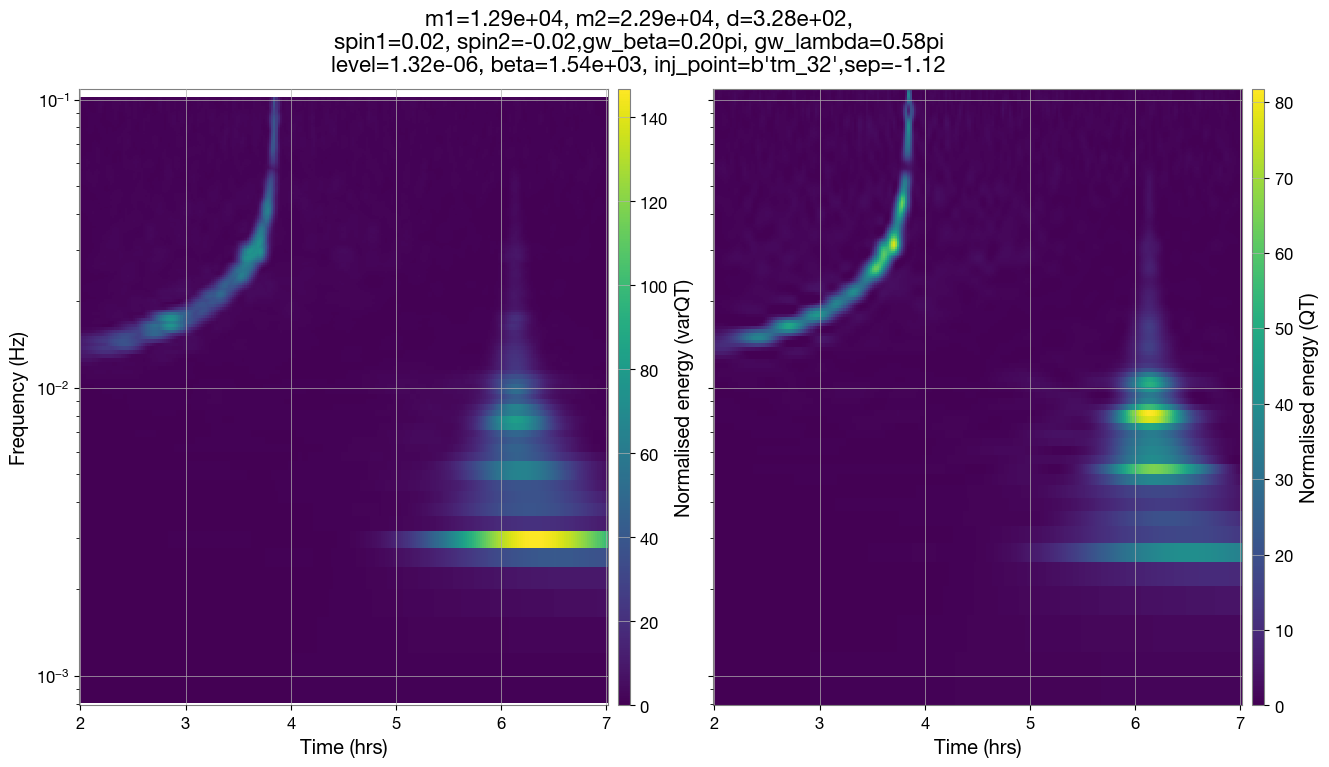

In [239]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
gw_title = title = f'm1={m1:.2e}, m2={m2:.2e}, d={d:.2e}, \n' +\
    f'spin1={spin1:.2f}, spin2={spin2:.2f},' +\
    f'gw_beta={gw_beta/np.pi:.2f}pi, gw_lambda={gw_lambda/np.pi:.2f}pi \n'
glitch_title = f'level={level:.2e}, beta={beta:.2e}, inj_point={inj_point},' +\
                f'sep={sep:.2f} \n'
fig.suptitle(gw_title + glitch_title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()

## Empty

In [17]:
with h5py.File(empty_dataset_path, "r") as h5:
    X_array = h5["X"][:]       # shape (N, 512, 512)
    Y_array = h5["Y"][:]       # shape (N, 512, 512)
    Z_array = h5["Z"][:]       # shape (N, 512, 512)

In [18]:
index = 978  # Change this index to visualize different samples
tdi_dict = make_tdi_dict(X_array[index], Y_array[index], Z_array[index], whiten=True)
pipe = {'t0': 10368000, 'dt': 0.25,'size': 10 * 3600 / 0.25, 't_inj': 5 * 3600}
specs = {'low_mass': {'trange':(-3, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

In [21]:
event = {'t_inj': pipe['t_inj']}
channel = 'A'
res = 256
spec = specs['low_mass']

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

4.26777195930481


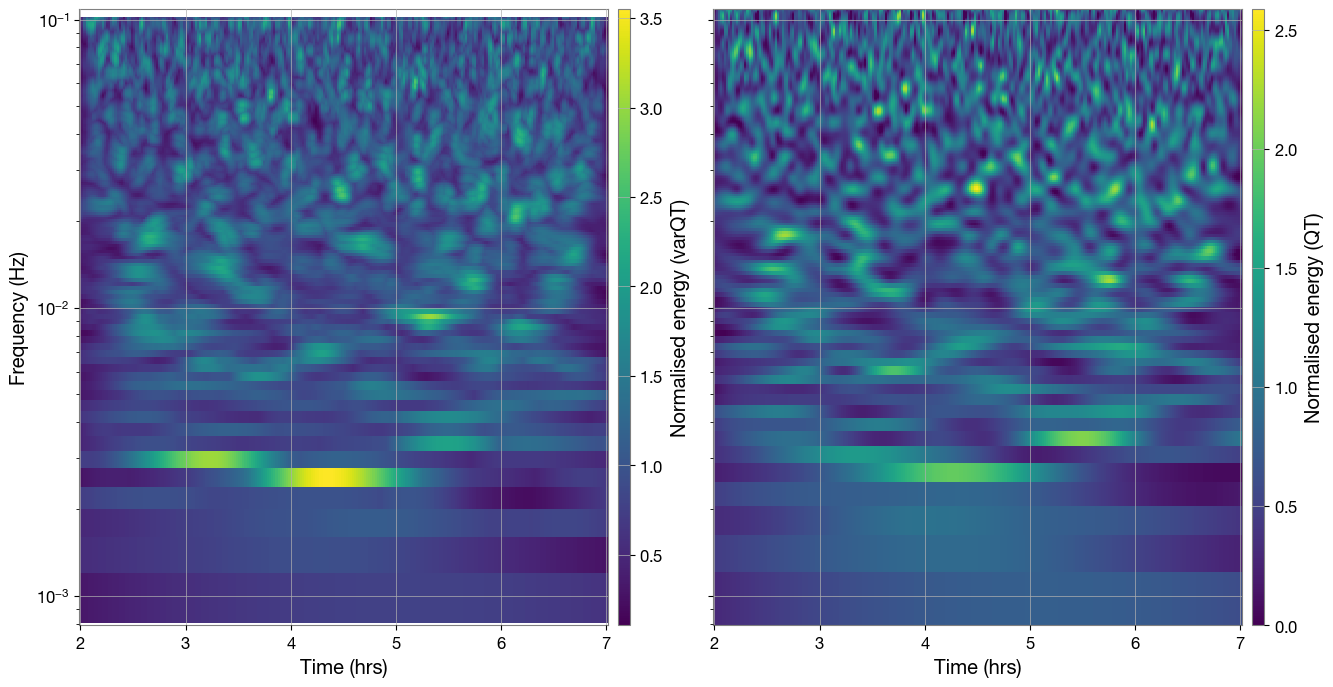

In [22]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()